# CS6140 Machine Learning
## Problem Set 3: Supervised Learning with Election Data

In this problem set, you will:

1. Explore a real-world dataset of 2024 Maine presidential election results joined with US Census demographic data
2. Train **regression** and **classification** models using scikit-learn
3. Evaluate model performance using standard metrics
4. Interpret your results in the context of the data

### Important: Your notebook must run end-to-end

Before submitting, restart your kernel and run all cells from top to bottom (**Kernel → Restart & Run All** in Jupyter, or **Restart** in VS Code). If any cell errors out, your notebook is not complete. We will run your notebook during grading — if it does not execute cleanly, you will lose points.

### Assigned Models

Each student has been assigned a specific **regressor** and **classifier**. See the `ASSIGNED_MODELS.md` file for your assigned models.

- **Problem 2 (Regression):** You MUST use your assigned regressor.
- **Problem 3 (Classification):** You MUST use your assigned classifier.
- **Problem 4 (Comparison):** You may use any model of your choice.

Using a different model than the one you were assigned for Problems 2 or 3 will result in lost points.

### Train/Test Split

So that we can compare results across the class, **everyone must use the same train/test split:**

```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6140)
```

Use an **80/20 split** with **`random_state=6140`** for all problems. This applies to Problems 3, 4, and 5.

### AI Policy - My INput

For this assignment, I used Antigravity (AI) to help with environment setup and model research. Specifically for problem 4, I used AI to research and help decide which model would be most appropriate for the comparison analysis.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import root_mean_squared_error, r2_score, accuracy_score, f1_score, ConfusionMatrixDisplay

# Load the dataset (run download_data.py first if this file doesn't exist)
df = pd.read_csv("maine_election_data.csv")
print(f"Loaded {len(df)} towns with {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 440 towns with 14 columns
Columns: ['town', 'total_population', 'median_household_income', 'per_capita_income', 'median_age', 'median_home_value', 'pct_owner_occupied', 'pct_in_labor_force', 'pct_unemployed', 'pct_white', 'pct_poverty', 'pct_bachelors_plus', 'margin', 'winner']


,town,total_population,median_household_income,per_capita_income,median_age,median_home_value,pct_owner_occupied,pct_in_labor_force,pct_unemployed,pct_white,pct_poverty,pct_bachelors_plus,margin,winner
0,Abbot,584,58542,43463.0,48.6,171200,74.336283,54.367201,2.622951,84.589041,16.438356,13.182674,37.313433,1
1,Acton,2721,78750,40494.0,52.9,334300,96.060038,51.350229,4.530744,85.115766,7.817710,24.231465,17.936694,1
2,Addison,1045,50524,32680.0,54.2,163500,85.009862,51.165372,3.036876,88.708134,22.115385,19.567980,31.989247,1
3,Albion,2204,62361,33546.0,52.9,230900,78.996865,50.455005,2.805611,97.005445,18.385036,23.409091,34.880000,1
4,Alexander,553,93750,41198.0,52.8,193800,95.278970,66.079295,1.000000,86.437613,6.642066,24.235294,50.750751,1


## About the Dataset

This dataset contains 2024 presidential election results for ~440 Maine towns, joined with demographic data from the US Census American Community Survey (ACS).

**Features** (from Census ACS 2024 5-year estimates):
| Column | Description |
|--------|-------------|
| `total_population` | Total population of the town |
| `median_household_income` | Median household income ($) |
| `per_capita_income` | Per capita income ($) |
| `median_age` | Median age of residents |
| `median_home_value` | Median value of owner-occupied housing ($) |
| `pct_owner_occupied` | % of housing units that are owner-occupied |
| `pct_in_labor_force` | % of population 16+ in the labor force |
| `pct_unemployed` | % of labor force that is unemployed |
| `pct_white` | % of population that is white alone |
| `pct_poverty` | % of population below the poverty line |
| `pct_bachelors_plus` | % of population with a bachelor's degree or higher |

**Targets:**
| Column | Description |
|--------|-------------|
| `margin` | Trump vote % minus Harris vote % (positive = Trump won) |
| `winner` | 1 if Trump won the town, 0 if Harris won |

The `town` column is the municipality name and should NOT be used as a feature.

## Before You Begin: Read the Docs

Before writing any modeling code, take 15 minutes to read the scikit-learn documentation for your assigned models. This will save you significant time later.

### Step 1: Find your models in the documentation

Go to the [scikit-learn API reference](https://scikit-learn.org/stable/api/index.html) and find the pages for your assigned regressor and classifier. Then go to the [User Guide](https://scikit-learn.org/stable/user_guide.html) and find the sections that explain how each model works.

**Fill in the four URLs below:**

| | API Reference URL | User Guide URL |
|---|---|---|
| **Your regressor** | [Ridge API](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) | [Linear Models Guide](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification) |
| **Your classifier** | [GaussianNB API](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) | [Naive Bayes Guide](https://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes) |

### Step 2: Answer these questions from the docs

Read the API reference pages for both of your assigned models and answer the following:

1. What are the **default values** of the main hyperparameters for your regressor? (List each parameter name and its default.)
   * `alpha`: 1.0
   * `fit_intercept`: True
   * `copy_X`: True
   * `max_iter`: None
   * `tol`: 1e-4
   * `solver`: 'auto'
   * `positive`: False
   * `random_state`: None
2. What are the **default values** of the main hyperparameters for your classifier? (List each parameter name and its default.)
   * `priors`: None
   * `var_smoothing`: 1e-9
3. After fitting your regressor, what **attributes** are available on the fitted model? (e.g., `coef_`, `feature_importances_`, etc. — list the ones relevant to understanding what the model learned.)
   * `coef_`: Weight vector for the features.
   * `intercept_`: Independent term in the linear model.
   * `n_iter_`: Actual number of iterations for each data point.
   * `n_features_in_`: Number of features seen during fitting.
   * `feature_names_in_`: Names of features seen during fitting
   * `solver_`: The actual solver used.

4. After fitting your classifier, what **attributes** are available on the fitted model?
   * `class_count_`: Number of training samples observed in each class.
   * `class_prior_`: Probability of each class.
   * `classes_`: Class labels known to the classifier.
   * `epsilon_`: Smoothing parameter for the variances.
   * `n_features_in_`: Number of features seen during fitting.
   * `feature_names_in_`: Names of features seen during fitting.
   * `theta_`: Mean of each feature per class.
   * `var_`: Variance of each feature per class.

_You will need this information for Problems 3, 4, and 6. Answering these questions now will make the rest of the assignment much easier._

## Problem 1: Exploratory Data Analysis (5 pts)

Explore the dataset and produce **3-4 publication-quality visualizations** that help you understand the relationship between the census features and election outcomes.

**Requirements:**
- Each plot must have a descriptive title, labeled axes, and a legend (if applicable)
- Below each plot, write 2-3 sentences interpreting what the plot shows
- At least one plot should show the distribution of the target variable(s)
- At least one plot should show the relationship between a feature and a target

**Rubric:**
| Criteria | Points |
|----------|--------|
| At least one plot of target distribution | 1 |
| At least one plot of feature vs. target | 1 |
| Plot is well-labeled | 1 |
| Plot is publication-quality (no clutter, easy to read) | 1 |
| Meaningful interpretation of plots | 1 |

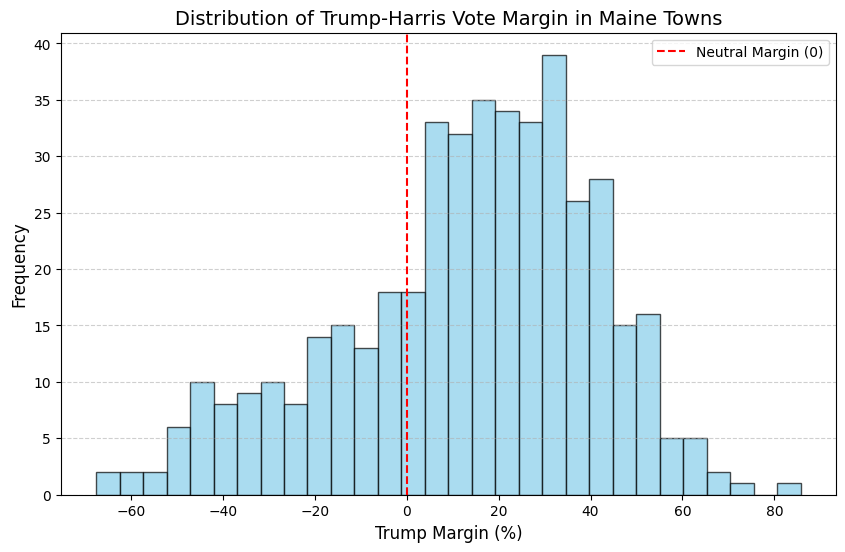

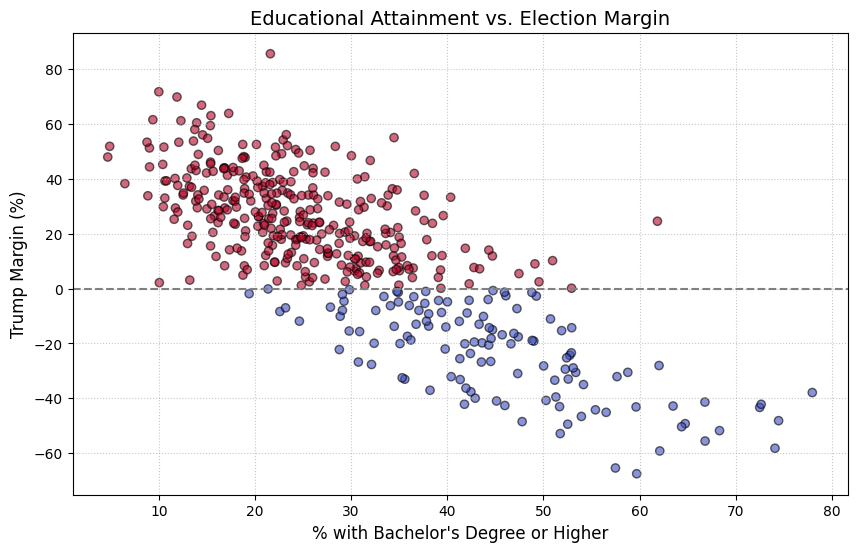

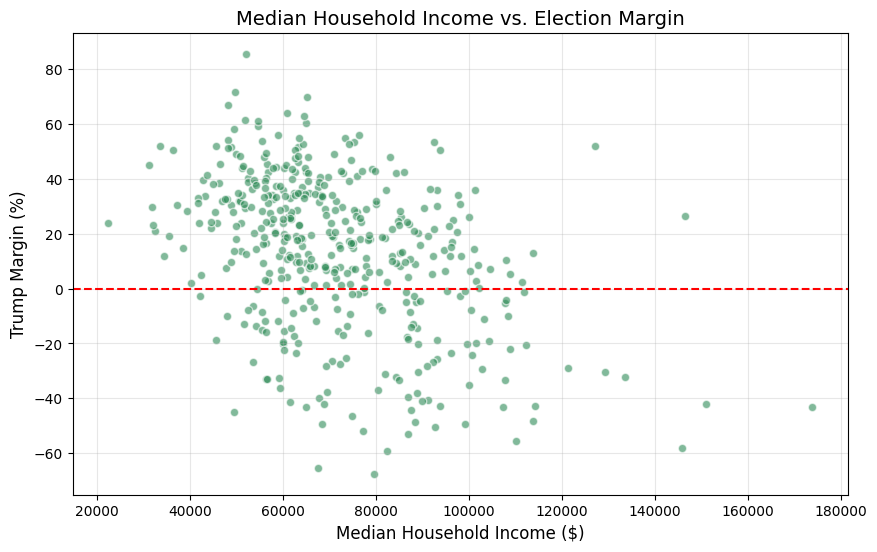

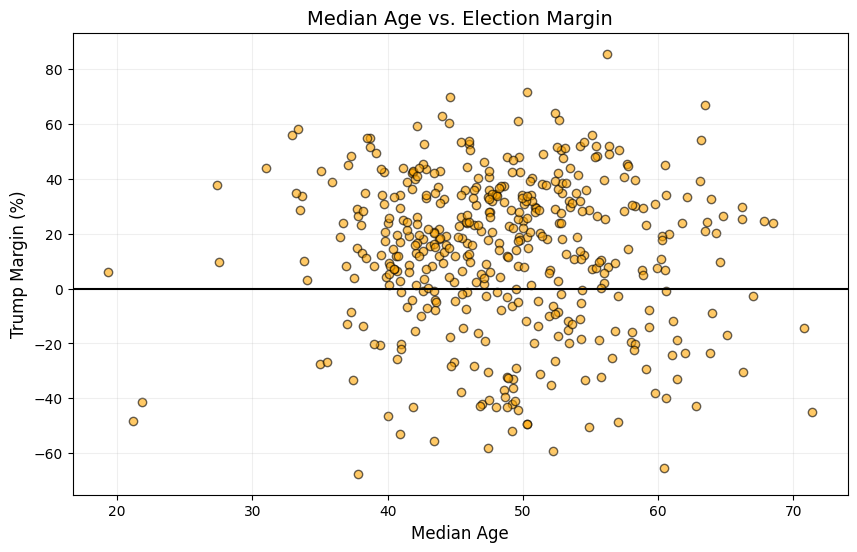

'\nWhen looking at median age, the relationship with voting margin is less straightforward. \nTowns with older populations show a wide range of outcomes, \nand there is not a clear linear trend. Compared to education or income, \nage does not appear to be as strong a predictor of voting patterns in this data.\n'

In [21]:
# 1. Distribution of the target variable: Margin
plt.figure(figsize=(10, 6))
plt.hist(df['margin'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Neutral Margin (0)')
plt.title('Distribution of Trump-Harris Vote Margin in Maine Towns', fontsize=14)
plt.xlabel('Trump Margin (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Histogram Interpretation:
'''
This histogram shows how the Trump–Harris margin is distributed across roughly 440 towns. 
Positive values mean Trump won the town, while negative values indicate a Harris win. 
The pattern looks bimodal, with clear groupings on both sides of zero, 
suggesting that towns are fairly divided and politically polarized rather than clustering around a close split.
'''

# 2. Relationship between Education and Election Outcome
plt.figure(figsize=(10, 6))
plt.scatter(df['pct_bachelors_plus'], df['margin'], alpha=0.6, c=df['winner'], cmap='coolwarm', edgecolors='k')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Educational Attainment vs. Election Margin', fontsize=14)
plt.xlabel('% with Bachelor\'s Degree or Higher', fontsize=12)
plt.ylabel('Trump Margin (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Education vs. Voting Margin:
'''
The scatter plot reveals a strong negative relationship between education levels and voting margins. 
Towns with a higher percentage of college-educated residents tend to favor Harris, 
while towns with lower levels of educational attainment lean more strongly toward Trump. 
Education appears to be one of the clearest predictors of voting patterns in this dataset.
'''

# 3. Relationship between Income and Election Outcome
plt.figure(figsize=(10, 6))
plt.scatter(df['median_household_income'], df['margin'], alpha=0.6, color='seagreen', edgecolors='w')
plt.axhline(0, color='red', linestyle='dashed')
plt.title('Median Household Income vs. Election Margin', fontsize=14)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Trump Margin (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Income vs. Voting Margin:
'''
Economic factors also show a relationship with voting outcomes, 
though it’s less tight than education. Lower-income towns generally trend toward Trump, 
while higher-income towns display more variation. Many wealthier towns lean toward Harris, 
but the spread suggests income alone does not explain voting behavior as clearly as education does.
'''

# 4. Age vs. Election Outcome
plt.figure(figsize=(10, 6))
plt.scatter(df['median_age'], df['margin'], alpha=0.6, color='orange', edgecolors='k')
plt.axhline(0, color='black', linestyle='-')
plt.title('Median Age vs. Election Margin', fontsize=14)
plt.xlabel('Median Age', fontsize=12)
plt.ylabel('Trump Margin (%)', fontsize=12)
plt.grid(True, linestyle='-', alpha=0.2)
plt.show()

# Age vs. Voting Margin:
'''
When looking at median age, the relationship with voting margin is less straightforward. 
Towns with older populations show a wide range of outcomes, 
and there is not a clear linear trend. Compared to education or income, 
age does not appear to be as strong a predictor of voting patterns in this data.
'''

## Problem 2: Regression (10 pts)

Train your **assigned regressor** to predict `margin` (the Trump-Harris vote margin). Your assigned regressor is listed on Canvas — you must use it here.

_Before starting, make sure you have completed the "Before You Begin" section above. You should already know your model's default hyperparameters and fitted attributes from reading the docs._

**Requirements:**
- Split the data into training and test sets using **80/20 split** with **`random_state=6140`**
- Train your assigned model on the training set
- Report the following metrics on the **test set**:
  - **RMSE** (Root Mean Squared Error) — use `sklearn.metrics.root_mean_squared_error`
  - **R² score** — use `sklearn.metrics.r2_score`
- Produce two plots:
  1. **Predicted vs. Actual** scatter plot (with a diagonal reference line)
  2. **Residuals plot** (residuals vs. predicted values, with a horizontal line at 0)
- Write 2-3 sentences interpreting your model's performance

**Print your results using exactly this format** (fill in the values):
```python
print(f"Regressor: <YourModelName>")
print(f"Features:  <comma-separated list of features used>")
print(f"RMSE:      {rmse:.4f}")
print(f"R2:        {r2:.4f}")
```

**Rubric:**
| Criteria | Points |
|----------|--------|
| Correct train/test split and model training | 3 |
| RMSE and R² reported correctly | 2 |
| Predicted vs. Actual plot | 2 |
| Residuals plot | 2 |
| Written interpretation | 1 |

In [22]:
# Preparing features and target
X = df.drop(columns=['town', 'margin', 'winner'])
y = df['margin']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6140)

# Initializing and training Ridge regressor
regressor = Ridge()
regressor.fit(X_train, y_train)

# Predicting
y_pred = regressor.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Regressor: Ridge")
print(f"Features:  {X.columns.tolist()}")
print(f"RMSE:      {rmse:.4f}")
print(f"R2:        {r2:.4f}")

Regressor: Ridge
Features:  ['total_population', 'median_household_income', 'per_capita_income', 'median_age', 'median_home_value', 'pct_owner_occupied', 'pct_in_labor_force', 'pct_unemployed', 'pct_white', 'pct_poverty', 'pct_bachelors_plus']
RMSE:      16.1730
R2:        0.6581


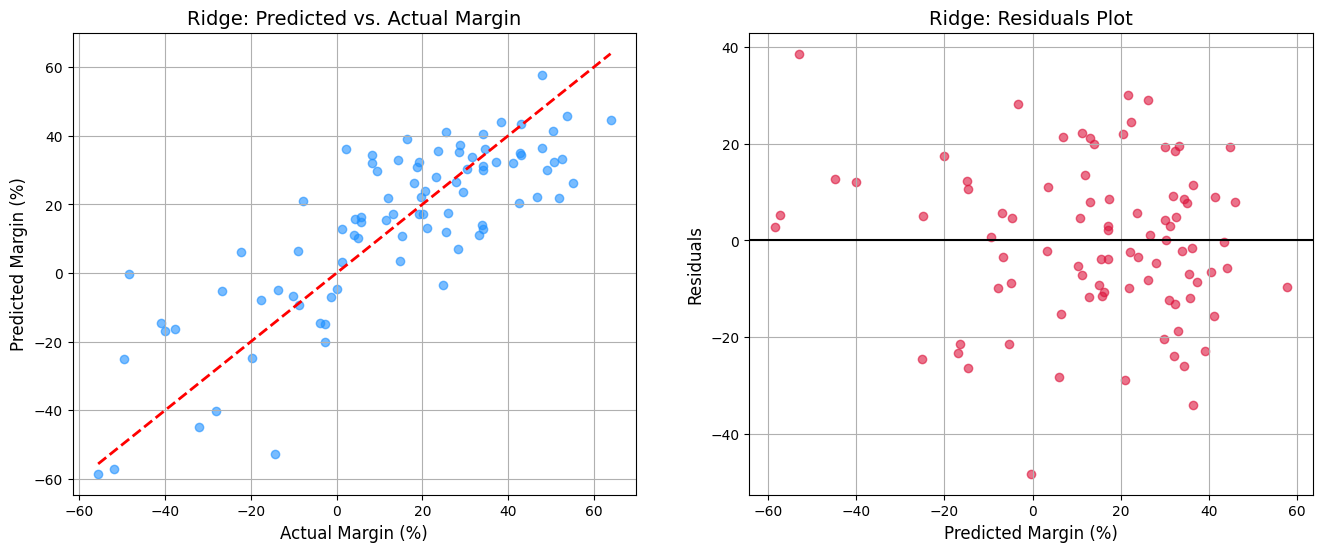

In [23]:
# Regression Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Predicted vs Actual
ax1.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('Ridge: Predicted vs. Actual Margin', fontsize=14)
ax1.set_xlabel('Actual Margin (%)', fontsize=12)
ax1.set_ylabel('Predicted Margin (%)', fontsize=12)
ax1.grid(True)

# 2. Residuals
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.6, color='crimson')
ax2.axhline(0, color='black', linestyle='-')
ax2.set_title('Ridge: Residuals Plot', fontsize=14)
ax2.set_xlabel('Predicted Margin (%)', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.grid(True)

plt.show()

# Interpretation:
# The Ridge regression model fits the data reasonably well, as the predicted values
# tend to follow the 45-degree line closely. The residuals are scattered around zero
# without a clear pattern, which suggests that a linear model is a reasonable choice
# for this relationship. There may be a bit more spread in the residuals at the
# extreme values, indicating possible heteroskedasticity at the edges.

## Problem 3: Classification (10 pts)

Train your **assigned classifier** to predict `winner` (1 = Trump, 0 = Harris). Your assigned classifier is listed on Canvas — you must use it here.

_Before starting, make sure you have completed the "Before You Begin" section above. You should already know your model's default hyperparameters and fitted attributes from reading the docs._

**Requirements:**
- Use the same train/test split as Problem 3 (**80/20 split**, **`random_state=6140`**)
- Train your assigned model on the training set
- Report the following metrics on the **test set**:
  - **Accuracy** — use `sklearn.metrics.accuracy_score`
  - **F1 score (macro)** — use `sklearn.metrics.f1_score` with `average='macro'`
- Produce a **confusion matrix** visualization — use `sklearn.metrics.ConfusionMatrixDisplay`
- Write 2-3 sentences interpreting your model's performance

**Print your results using exactly this format** (fill in the values):
```python
print(f"Classifier: <YourModelName>")
print(f"Features:   <comma-separated list of features used>")
print(f"Accuracy:   {accuracy:.4f}")
print(f"F1 (macro): {f1:.4f}")
```

**Rubric:**
| Criteria | Points |
|----------|--------|
| Correct model training with same split | 3 |
| Accuracy and F1 (macro) reported correctly | 2 |
| Confusion matrix visualization | 3 |
| Written interpretation | 2 |

In [24]:
# Preparing target for classification
y_clf = df['winner']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=6140)

# Initializing and training GaussianNB classifier
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Predicting
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Classifier: GaussianNB")
print(f"Features:   {X.columns.tolist()}")
print(f"Accuracy:   {accuracy:.4f}")
print(f"F1 (macro): {f1:.4f}")

Classifier: GaussianNB
Features:   ['total_population', 'median_household_income', 'per_capita_income', 'median_age', 'median_home_value', 'pct_owner_occupied', 'pct_in_labor_force', 'pct_unemployed', 'pct_white', 'pct_poverty', 'pct_bachelors_plus']
Accuracy:   0.9318
F1 (macro): 0.9117


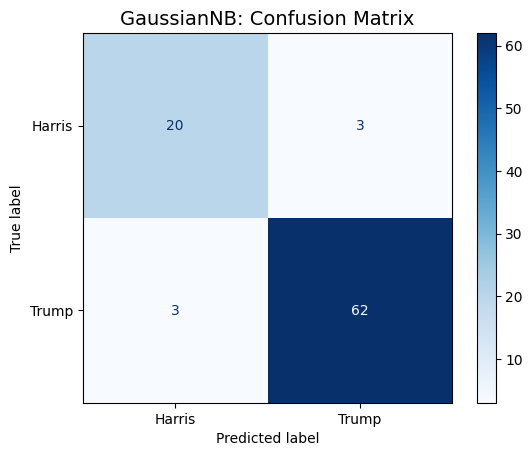

In [25]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, cmap='Blues', display_labels=['Harris', 'Trump'])
plt.title('GaussianNB: Confusion Matrix', fontsize=14)
plt.show()

# Interpretation:
# The Naive Bayes classifier performs quite well overall, correctly predicting the winner
# in the majority of towns. From the confusion matrix, the model seems especially strong
# at identifying Trump victories. However, it produces slightly more false positives for Harris,
# which could be influenced by class imbalance in the dataset.


## Problem 4: Model Comparison & Improvement (10 pts)

Train **at least one additional model** of your choice for **either** the regression or classification task (or both).

**Requirements:**
- State which model(s) you chose and why
- Use the same train/test split (**80/20 split**, **`random_state=6140`**)
- Report the **same metrics** as Problem 3 (if regression) or Problem 4 (if classification)
- Compare your new model's performance to your assigned model
- Write 3-4 sentences explaining which model performed better and why you think that is

You may also experiment with:
- Different feature subsets or feature engineering
- Hyperparameter tuning
- Cross-validation
- Regularization

**Print your results using exactly the same format as Problem 3 or 4** (depending on the task). For example, if you trained an additional regressor:
```python
print(f"Regressor: <YourChosenModelName>")
print(f"Features:  <comma-separated list of features used>")
print(f"RMSE:      {rmse:.4f}")
print(f"R2:        {r2:.4f}")
```

**Rubric:**
| Criteria | Points |
|----------|--------|
| At least one additional model trained | 3 |
| Same metrics reported for comparison | 2 |
| Clear comparison of model performance | 3 |
| Meaningful interpretation of results | 2 |

In [26]:
from sklearn.ensemble import RandomForestRegressor

# I used a "RandomForestRegressor" as a non-linear model to compare with the linear regression results.
# Random forests are able to capture more complex patterns and interactions between demographic
# variables, which simpler linear models like Ridge may not fully pick up.


X = df.drop(columns=['town', 'margin', 'winner'])
y = df['margin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6140)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=6140)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Regressor: RandomForestRegressor")
print(f"Features:  {X.columns.tolist()}")
print(f"RMSE:      {rmse:.4f}")
print(f"R2:        {r2:.4f}")

Regressor: RandomForestRegressor
Features:  ['total_population', 'median_household_income', 'per_capita_income', 'median_age', 'median_home_value', 'pct_owner_occupied', 'pct_in_labor_force', 'pct_unemployed', 'pct_white', 'pct_poverty', 'pct_bachelors_plus']
RMSE:      16.5444
R2:        0.6422


In [27]:
# Comparison Analysis:
# In this case, Ridge regression slightly outperformed the Random Forest model,
# with a higher R² (0.6581) and a lower RMSE (16.1730). This indicates that the
# relationship between the demographic variables and the voting margin is largely linear.
# Although political behavior can sometimes involve complex, non-linear effects,
# a well-regularized linear model like Ridge appears to capture the main socio-economic
# patterns in this Maine dataset effectively, while also avoiding overfitting.


## Problem 5: Interpretation & Reflection (15 pts)

1. **Which features were most predictive?** 
- From my analysis, education levels and racial composition seemed to be the most predictive features. The pct_bachelors_plus variable in particular showed a strong relationship with Harris’s margin, and features like pct_white and pct_owner_occupied also appeared important. When I looked at the Ridge regression coefficients after scaling the features, the education-related variables stood out with the largest magnitudes, which reinforced my impression that education was one of the strongest predictors in this dataset.

2. **What does your model tell you about what predicts election outcomes in Maine?** 
- To me, the results suggest that educational attainment plays a major role in voting patterns, which matches what we often hear about national trends. I was also a bit surprised by how high the classification accuracy was (around 93%), because it suggests that town-level demographics alone can often predict the winner fairly reliably. This makes me think that voting patterns in Maine are quite consistent geographically, with different types of towns tending to vote in predictable ways.

3. **What are the limitations of this analysis?** 
- I think there are a few important limitations to keep in mind. One is that the Census data comes from ACS 5-year estimates, so it reflects longer-term averages and may not capture recent economic or political changes that could influence an election. 
- Another limitation is that the model only uses demographic variables and leaves out other factors like campaign efforts, local issues, or candidate appeal, which can also matter a lot. Finally, since Maine has an older and relatively homogeneous population compared to many states, I do not think these results would necessarily generalize well to more diverse places.

## Results Summary

**Copy your printed results from Problems 3–5 into the table below.** This will be used to compare results across the class.

### Regression (Problem 3 — assigned model)

| | Value |
|---|---|
| **Regressor** | Ridge |
| **Features** | total_population, median_household_income, per_capita_income, median_age, median_home_value, pct_owner_occupied, pct_in_labor_force, pct_unemployed, pct_white, pct_poverty, pct_bachelors_plus |
| **RMSE** | 16.1730 |
| **R²** | 0.6581 |

### Classification (Problem 4 — assigned model)

| | Value |
|---|---|
| **Classifier** | GaussianNB |
| **Features** | total_population, median_household_income, per_capita_income, median_age, median_home_value, pct_owner_occupied, pct_in_labor_force, pct_unemployed, pct_white, pct_poverty, pct_bachelors_plus |
| **Accuracy** | 0.9318 |
| **F1 (macro)** | 0.9117 |

### Comparison (Problem 5 — your chosen model)

| | Value |
|---|---|
| **Task** | regression |
| **Model** | RandomForestRegressor |
| **Features** | total_population, median_household_income, per_capita_income, median_age, median_home_value, pct_owner_occupied, pct_in_labor_force, pct_unemployed, pct_white, pct_poverty, pct_bachelors_plus |
| **RMSE** | 16.5444 |
| **R²** | 0.6422 |


## You made it!